- Train Naive Bayes OR Boosting classifier
- Classify segmented objects/regions

### Pipeline:
Image
→ Gaussian + Median filtering
→ Segmentation (K-means)
→ Feature Extraction (SIFT + BoVW)
→ Classification (Boosting)
→ 4-class prediction

In [1]:
from pathlib import Path
import sys

# BASE_DIR = Path(__file__).resolve().parent
BASE_DIR = Path().resolve().parent

sys.path.append(str(BASE_DIR))

# train_path = BASE_DIR / "data" / "raw" / "Training"
# test_path = BASE_DIR / "data" / "raw" / "Testing"


train_path = Path("data/raw/Training").resolve()
test_path  = Path("data/raw/Testing").resolve()

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from modules.data_loader import load_data
from modules.preprocessing import preprocess
from modules.segmentation import kmeans_segmentation
from modules.sift import get_sift_features, build_vocabulary, image_to_feature


In [3]:
X_train, y_train = load_data(train_path)
X_test, y_test = load_data(test_path)

# Apply preprocessing to the loaded data (includes filtering)
X_train = [preprocess(img) for img in X_train]
X_test = [preprocess(img) for img in X_test]

In [4]:
# Apply segmentation to the preprocessed images
X_train_segmented = [kmeans_segmentation(img) for img in X_train]
X_test_segmented = [kmeans_segmentation(img) for img in X_test]

In [5]:
# Build visual vocabulary using SIFT features from the segmented training images
descriptor_list = []

for img in X_train:
    _, des = get_sift_features(img)
    if des is not None:
        descriptor_list.append(des)
        

kmeans = build_vocabulary(descriptor_list, vocab_size=200)

C:\Users\khebr\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\khebr\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\khebr\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwar

In [6]:
# Extract SIFT features from segmented images
X_train_features = [image_to_feature(img, kmeans, vocab_size=200) for img in X_train]
X_test_features = [image_to_feature(img, kmeans, vocab_size=200) for img in X_test]

In [7]:
import pandas as pd
pd.Series(y_train).value_counts()


glioma        1400
meningioma    1400
notumor       1400
pituitary     1400
Name: count, dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

### Boosting Classifier

In [16]:
from sklearn.ensemble import GradientBoostingClassifier

model1 = GradientBoostingClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5
    )
model1.fit(X_train_features, y_train_enc)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [17]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model1.predict(X_test_features)

print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Accuracy: 0.790625
              precision    recall  f1-score   support

      glioma       0.76      0.60      0.67       400
  meningioma       0.70      0.78      0.74       400
     notumor       0.91      0.99      0.95       400
   pituitary       0.79      0.80      0.79       400

    accuracy                           0.79      1600
   macro avg       0.79      0.79      0.79      1600
weighted avg       0.79      0.79      0.79      1600



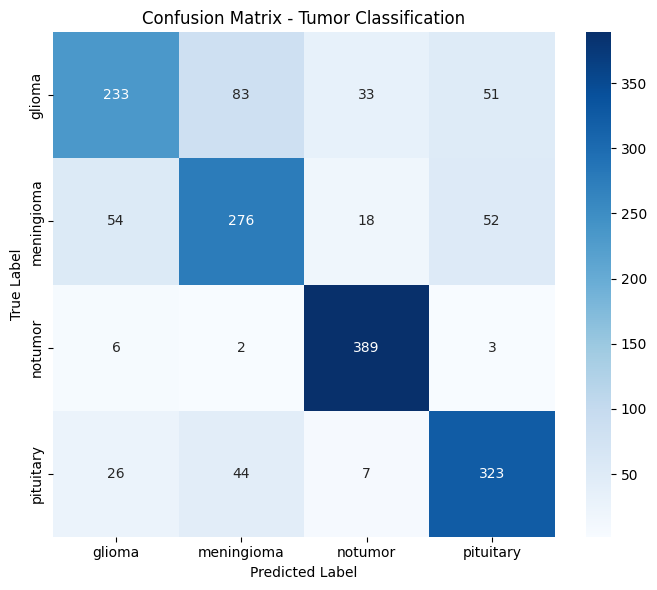

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix - Tumor Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

### XG Boost Classifier

In [12]:
from xgboost import XGBClassifier

model2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=4,
    random_state=42
)

model2.fit(X_train_features, y_train_enc)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [13]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model2.predict(X_test_features)

print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Accuracy: 0.8
              precision    recall  f1-score   support

      glioma       0.82      0.59      0.69       400
  meningioma       0.69      0.78      0.74       400
     notumor       0.90      0.99      0.95       400
   pituitary       0.79      0.83      0.81       400

    accuracy                           0.80      1600
   macro avg       0.80      0.80      0.80      1600
weighted avg       0.80      0.80      0.80      1600



### Entire Pipeline Function

In [14]:
# Function that applies the entire pipeline to a single image
def classify_image(image_path, model, kmeans, le):
    img = cv2.imread(image_path)
    img_preprocessed = preprocess(img)
    img_segmented = kmeans_segmentation(img_preprocessed)
    img_feature = image_to_feature(img_segmented, kmeans, vocab_size=200)
    img_feature = img_feature.reshape(1, -1)  # Reshape for prediction
    pred_label_enc = model.predict(img_feature)[0]
    pred_label = le.inverse_transform([pred_label_enc])[0]
    return pred_label

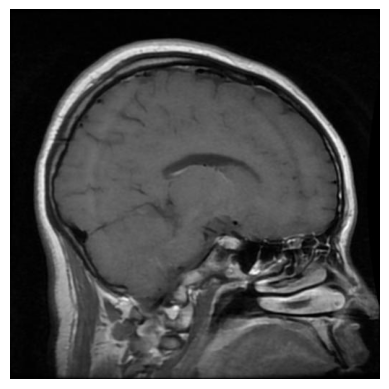

Predicted label for Te-pi_5.jpg (Gradient Boosting): pituitary
Predicted label for Te-pi_5.jpg (XGBoost): pituitary


In [15]:
# use function on a test image
test_image_path = test_path / "pituitary" / "Te-pi_5.jpg"
plt.imshow(cv2.imread(str(test_image_path)))
plt.axis('off')
plt.show()
predicted_label = classify_image(test_image_path, model1, kmeans, le)
print(f"Predicted label for {test_image_path.name} (Gradient Boosting): {predicted_label}")
predicted_label = classify_image(test_image_path, model2, kmeans, le)
print(f"Predicted label for {test_image_path.name} (XGBoost): {predicted_label}")